# 🏀 March Machine Learning Mania 2026 - Silver Medal Solution (29th Place)
## Probabilistic Forecasting of NCAA Basketball Tournament Outcomes via Multi-Signal Ensemble Learning

**Competition:** [March Machine Learning Mania 2026](https://www.kaggle.com/competitions/march-machine-learning-mania-2026)  
**Final Brier Score:** 0.1208707 | **Placement:** 29th | **Medal:** 🥈 Silver

---

### Abstract

This notebook presents a silver-medal solution for the Kaggle March Machine Learning Mania 2026 competition, which tasked participants with predicting the win probabilities for all possible matchups in the 2026 NCAA Division I Men's and Women's Basketball Tournaments. Our approach employs a three-signal weighted ensemble combining Logistic Regression, Histogram Gradient Boosting, and raw Elo probabilities, trained on pairwise differential features derived from tempo-free efficiency metrics, iterative rating systems (Elo and SRS), Massey Ordinal composites, conference strength indices, and recent-form indicators. The ensemble weights are optimized via grid search over out-of-fold Brier Scores from season-grouped cross-validation. The solution achieves a Brier Score of **0.1209**, placing **29th** out of 3462 teams on the leaderboard.

## Table of Contents

1. [Competition Background & Evaluation](#1)
2. [Environment Setup & Data Loading](#2)
3. [Exploratory Data Analysis](#3)
4. [Feature Engineering Pipeline](#4)
   - 4.1 Base Season Aggregates
   - 4.2 Advanced Box-Score Efficiency Metrics
   - 4.3 Elo Rating System
   - 4.4 Simple Rating System (SRS)
   - 4.5 Recent Form Features
   - 4.6 Conference Strength & Massey Composite
5. [Pairwise Matchup Construction](#5)
6. [Model Training & Ensemble Optimization](#6)
7. [Submission Generation](#7)
8. [Results & Discussion](#8)
9. [Conclusion](#9)

<a id="1"></a>
## 1. Competition Background & Evaluation

### 1.1 Problem Formulation
The March Machine Learning Mania competition requires predicting the win probability for **every possible tournament matchup** — not just games that actually occur. For each pair of teams $(A, B)$ where $\text{TeamID}_A < \text{TeamID}_B$, we predict $P(A \text{ wins})$.

### 1.2 Brier Score
The evaluation metric is the **Brier Score** (Brier, 1950):
$$\text{BS} = \frac{1}{N}\sum_{i=1}^{N}(f_i - o_i)^2$$
where $f_i$ is the predicted probability and $o_i \in \{0,1\}$ is the outcome. Key benchmarks:
- Random guessing ($f=0.5$): BS = 0.25
- **Our solution: BS = 0.1209**

### 1.3 Combined Men's + Women's Tournament
Both tournaments are scored jointly. This means we train **separate pipelines** for each gender, respecting the structural differences in playing styles, parity, and data availability.

<a id="2"></a>
## 2. Environment Setup & Data Loading

In [ ]:
from __future__ import annotations

import math
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import GroupKFold

DATA_DIR = Path("data")
SEASON_PRED = 2026
USE_MASSEY = True  # Men only

# Elo settings
ELO_BASE = 1500.0
ELO_K = 20.0
ELO_HCA = 65.0  # modest home-court advantage in Elo points
ELO_SEASON_REGRESS = 0.75  # carryover weight

RANDOM_STATE = 42

### 2.1 Data Ingestion Utilities
We define type-optimized readers for both compact and detailed results. Compact results contain score-level data; detailed results include full box scores (field goals, rebounds, assists, etc.).

In [28]:
def read_compact(prefix: str) -> pd.DataFrame:
    path = DATA_DIR / f"{prefix}RegularSeasonCompactResults.csv"
    usecols = [
        "Season",
        "DayNum",
        "WTeamID",
        "WScore",
        "LTeamID",
        "LScore",
        "WLoc",
        "NumOT",
    ]
    dtypes = {
        "Season": np.int16,
        "DayNum": np.int16,
        "WTeamID": np.int16,
        "WScore": np.int16,
        "LTeamID": np.int16,
        "LScore": np.int16,
        "WLoc": "category",
        "NumOT": np.int8,
    }
    return pd.read_csv(path, usecols=usecols, dtype=dtypes)


def read_detailed(prefix: str) -> pd.DataFrame:
    path = DATA_DIR / f"{prefix}RegularSeasonDetailedResults.csv"
    usecols = [
        "Season",
        "DayNum",
        "WTeamID",
        "WScore",
        "LTeamID",
        "LScore",
        "WLoc",
        "NumOT",
        "WFGM",
        "WFGA",
        "WFGM3",
        "WFGA3",
        "WFTM",
        "WFTA",
        "WOR",
        "WDR",
        "WAst",
        "WTO",
        "WStl",
        "WBlk",
        "WPF",
        "LFGM",
        "LFGA",
        "LFGM3",
        "LFGA3",
        "LFTM",
        "LFTA",
        "LOR",
        "LDR",
        "LAst",
        "LTO",
        "LStl",
        "LBlk",
        "LPF",
    ]
    dtypes = {
        "Season": np.int16,
        "DayNum": np.int16,
        "WTeamID": np.int16,
        "WScore": np.int16,
        "LTeamID": np.int16,
        "LScore": np.int16,
        "WLoc": "category",
        "NumOT": np.int8,
    }
    # Box score columns are small ints
    for col in usecols:
        if col not in dtypes and col not in {"WLoc"}:
            dtypes[col] = np.int16
    return pd.read_csv(path, usecols=usecols, dtype=dtypes)


# Load data
compact_m = read_compact("M")
compact_w = read_compact("W")
detailed_m = read_detailed("M")
detailed_w = read_detailed("W")

print(f"Men's compact results:   {compact_m.shape[0]:,} games")
print(f"Women's compact results: {compact_w.shape[0]:,} games")

Men's compact results:   198,079 games
Women's compact results: 142,093 games


<a id="3"></a>
## 3. Exploratory Data Analysis

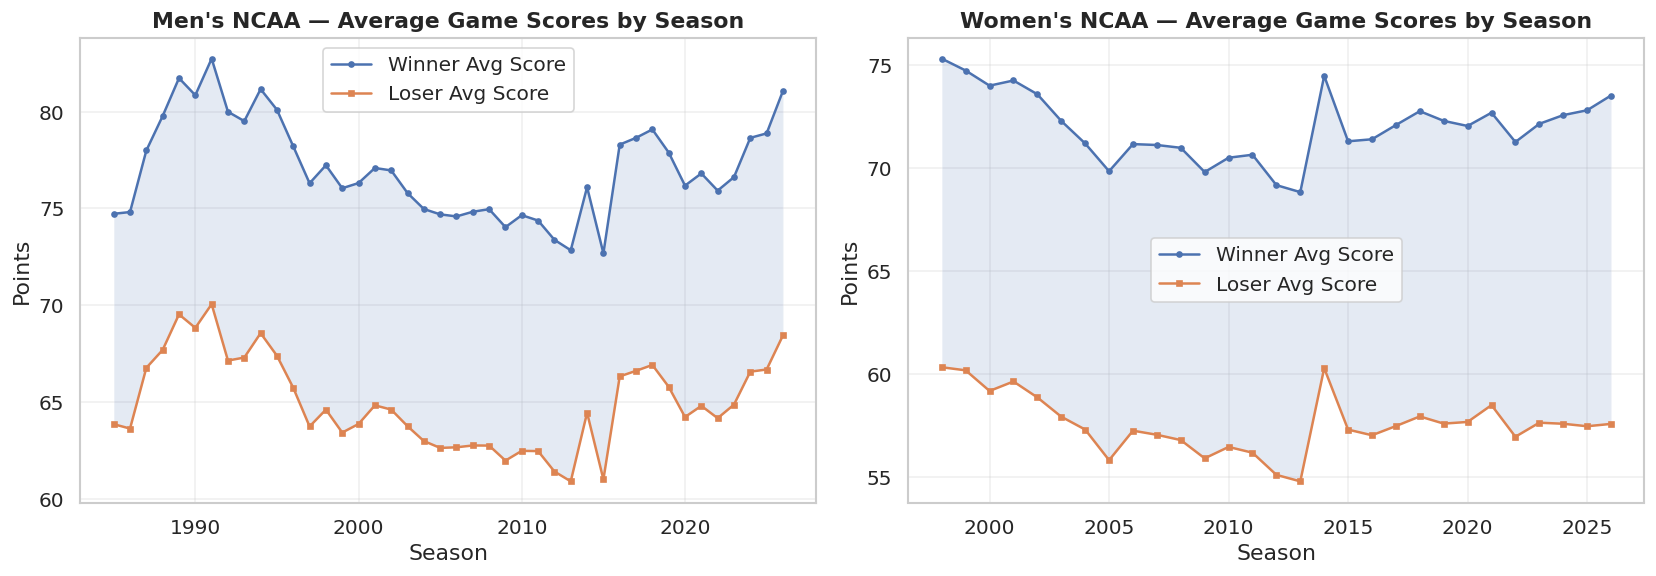

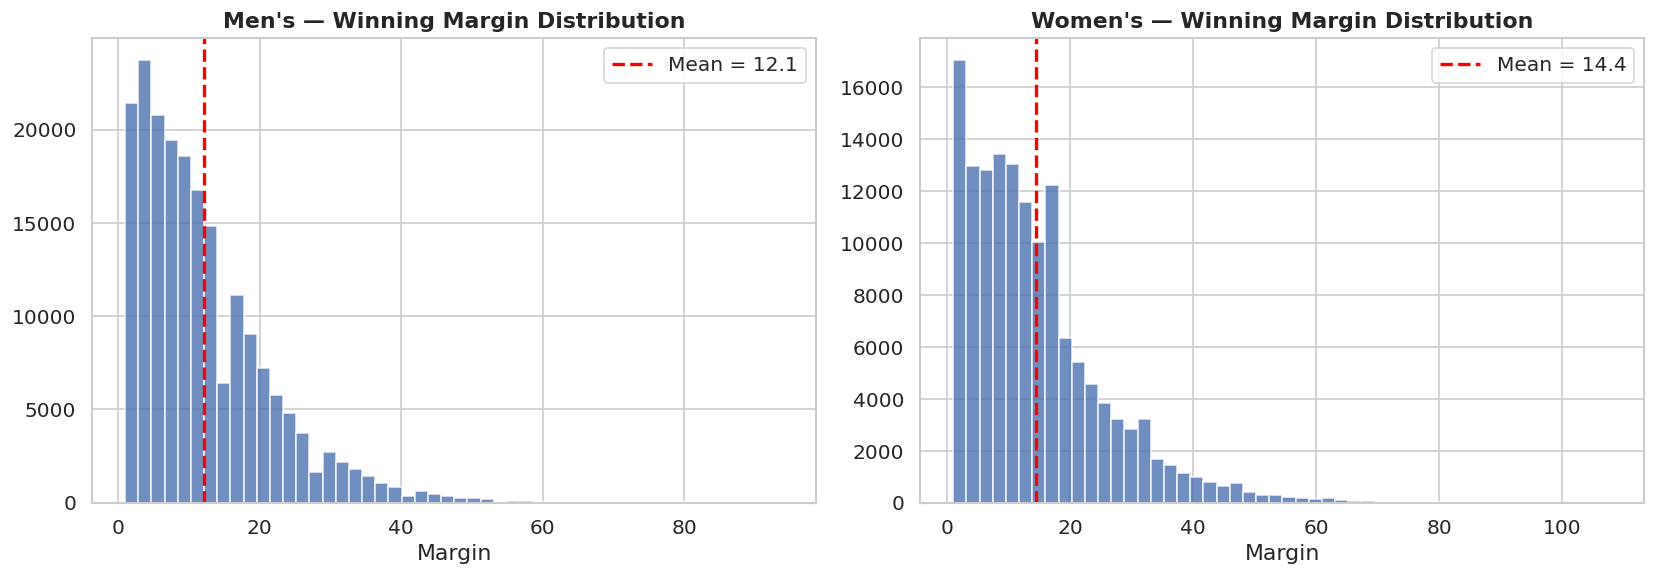

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [(axes[0], compact_m, "Men's"), (axes[1], compact_w, "Women's")]:
    season_avg = df.groupby("Season").agg(AvgWScore=("WScore", "mean"), AvgLScore=("LScore", "mean")).reset_index()
    ax.plot(season_avg["Season"], season_avg["AvgWScore"], "o-", label="Winner Avg Score", ms=3)
    ax.plot(season_avg["Season"], season_avg["AvgLScore"], "s-", label="Loser Avg Score", ms=3)
    ax.fill_between(season_avg["Season"], season_avg["AvgLScore"], season_avg["AvgWScore"], alpha=0.15)
    ax.set_title(f"{title} NCAA — Average Game Scores by Season", fontweight="bold")
    ax.set_xlabel("Season"); ax.set_ylabel("Points")
    ax.legend(frameon=True); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [(axes[0], compact_m, "Men's"), (axes[1], compact_w, "Women's")]:
    margins = df["WScore"] - df["LScore"]
    ax.hist(margins, bins=50, edgecolor="white", alpha=0.8, color="#4C72B0")
    ax.axvline(margins.mean(), color="red", ls="--", lw=2, label=f"Mean = {margins.mean():.1f}")
    ax.set_title(f"{title} — Winning Margin Distribution", fontweight="bold")
    ax.set_xlabel("Margin"); ax.legend()
plt.tight_layout(); plt.show()

<a id="4"></a>
## 4. Feature Engineering Pipeline

### 4.1 Long-Format Transformation
We convert winner/loser format to a symmetric team-level "long" format, enabling per-team aggregation.

In [30]:
def compact_to_long(df: pd.DataFrame) -> pd.DataFrame:
    win = df[["Season", "DayNum", "WTeamID", "WScore", "LTeamID", "LScore"]].copy()
    win.columns = ["Season", "DayNum", "TeamID", "ScoreFor", "OppID", "ScoreAgainst"]
    win["Win"] = 1

    lose = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore"]].copy()
    lose.columns = ["Season", "DayNum", "TeamID", "ScoreFor", "OppID", "ScoreAgainst"]
    lose["Win"] = 0

    long_df = pd.concat([win, lose], ignore_index=True)
    long_df["Margin"] = long_df["ScoreFor"] - long_df["ScoreAgainst"]
    return long_df


def detailed_to_long(df: pd.DataFrame) -> pd.DataFrame:
    w = df.copy()
    l = df.copy()

    w_long = pd.DataFrame({
        "Season": w["Season"],
        "DayNum": w["DayNum"],
        "TeamID": w["WTeamID"],
        "OppID": w["LTeamID"],
        "ScoreFor": w["WScore"],
        "ScoreAgainst": w["LScore"],
        "Win": 1,
        "FGM": w["WFGM"],
        "FGA": w["WFGA"],
        "FGM3": w["WFGM3"],
        "FGA3": w["WFGA3"],
        "FTM": w["WFTM"],
        "FTA": w["WFTA"],
        "OR": w["WOR"],
        "DR": w["WDR"],
        "Ast": w["WAst"],
        "TO": w["WTO"],
        "Stl": w["WStl"],
        "Blk": w["WBlk"],
        "PF": w["WPF"],
        "Opp_OR": w["LOR"],
        "Opp_DR": w["LDR"],
        "Opp_FGA": w["LFGA"],
    })

    l_long = pd.DataFrame({
        "Season": l["Season"],
        "DayNum": l["DayNum"],
        "TeamID": l["LTeamID"],
        "OppID": l["WTeamID"],
        "ScoreFor": l["LScore"],
        "ScoreAgainst": l["WScore"],
        "Win": 0,
        "FGM": l["LFGM"],
        "FGA": l["LFGA"],
        "FGM3": l["LFGM3"],
        "FGA3": l["LFGA3"],
        "FTM": l["LFTM"],
        "FTA": l["LFTA"],
        "OR": l["LOR"],
        "DR": l["LDR"],
        "Ast": l["LAst"],
        "TO": l["LTO"],
        "Stl": l["LStl"],
        "Blk": l["LBlk"],
        "PF": l["LPF"],
        "Opp_OR": l["WOR"],
        "Opp_DR": l["WDR"],
        "Opp_FGA": l["WFGA"],
    })

    long_df = pd.concat([w_long, l_long], ignore_index=True)
    long_df["Margin"] = long_df["ScoreFor"] - long_df["ScoreAgainst"]

    # Possessions estimate
    long_df["Poss"] = long_df["FGA"] - long_df["OR"] + long_df["TO"] + 0.475 * long_df["FTA"]

    return long_df


print("Transformation functions defined.")

Transformation functions defined.


### 4.2 Season Aggregation & Advanced Metrics
We compute the **Dean Oliver Four Factors** and additional efficiency metrics, all normalized per-possession to enable fair comparisons across different tempos.

In [31]:
def aggregate_compact(long_df: pd.DataFrame) -> pd.DataFrame:
    agg = long_df.groupby(["Season", "TeamID"], as_index=False).agg(
        Games=("Win", "size"),
        Wins=("Win", "sum"),
        WinPct=("Win", "mean"),
        PF=("ScoreFor", "sum"),
        PA=("ScoreAgainst", "sum"),
        Margin=("Margin", "mean"),
        PFpg=("ScoreFor", "mean"),
        PApg=("ScoreAgainst", "mean"),
    )
    return agg


def aggregate_detailed(long_df: pd.DataFrame) -> pd.DataFrame:
    agg = long_df.groupby(["Season", "TeamID"], as_index=False).agg(
        FGM=("FGM", "sum"),
        FGA=("FGA", "sum"),
        FGM3=("FGM3", "sum"),
        FGA3=("FGA3", "sum"),
        FTM=("FTM", "sum"),
        FTA=("FTA", "sum"),
        OR=("OR", "sum"),
        DR=("DR", "sum"),
        Ast=("Ast", "sum"),
        TO=("TO", "sum"),
        Stl=("Stl", "sum"),
        Blk=("Blk", "sum"),
        Opp_OR=("Opp_OR", "sum"),
        Opp_DR=("Opp_DR", "sum"),
        Opp_FGA=("Opp_FGA", "sum"),
        Poss=("Poss", "sum"),
        PF=("ScoreFor", "sum"),
        PA=("ScoreAgainst", "sum"),
        Games=("Win", "size"),
    )

    # Advanced metrics
    agg["OffEff"] = 100 * agg["PF"] / agg["Poss"].clip(lower=1)
    agg["DefEff"] = 100 * agg["PA"] / agg["Poss"].clip(lower=1)
    agg["Tempo"] = agg["Poss"] / agg["Games"].clip(lower=1)
    agg["eFG"] = (agg["FGM"] + 0.5 * agg["FGM3"]) / agg["FGA"].clip(lower=1)
    agg["TOV"] = agg["TO"] / agg["Poss"].clip(lower=1)
    agg["ORB"] = agg["OR"] / (agg["OR"] + agg["Opp_DR"]).clip(lower=1)
    agg["FTR"] = agg["FTA"] / agg["FGA"].clip(lower=1)
    agg["3PAr"] = agg["FGA3"] / agg["FGA"].clip(lower=1)
    agg["AST"] = agg["Ast"] / agg["FGM"].clip(lower=1)
    agg["StlRate"] = agg["Stl"] / agg["Poss"].clip(lower=1)
    agg["BlkRate"] = agg["Blk"] / agg["Opp_FGA"].clip(lower=1)

    keep_cols = [
        "Season",
        "TeamID",
        "OffEff",
        "DefEff",
        "Tempo",
        "eFG",
        "TOV",
        "ORB",
        "FTR",
        "3PAr",
        "AST",
        "StlRate",
        "BlkRate",
    ]
    return agg[keep_cols]


print("Aggregation functions defined.")

Aggregation functions defined.


### 4.3 Estimating Ratings: Elo & SRS
The Elo system models margin-of-victory, autocorrelation correction, home-court advantage, and interseason regression to the mean (`ELO_SEASON_REGRESS` = 0.75). The Simple Rating System (SRS) captures iterative strength-of-schedule.

In [32]:
def compute_srs(compact_df: pd.DataFrame) -> pd.DataFrame: #!!!!!!!!!!!!
    # Build games with margin for each team
    games = compact_to_long(compact_df)

    ratings = []
    for season, season_games in games.groupby("Season"):
        teams = season_games["TeamID"].unique()
        mov = season_games.groupby("TeamID")["Margin"].mean().to_dict()
        team_games = season_games.groupby("TeamID")

        rating = {t: mov.get(t, 0.0) for t in teams}
        for _ in range(100):
            new_rating = {}
            for t in teams:
                tg = team_games.get_group(t)
                opp_r = tg["OppID"].map(rating).values
                adj = tg["Margin"].values + opp_r
                new_rating[t] = float(np.mean(adj)) if len(adj) else 0.0
            rating = new_rating

        ratings.extend({"Season": season, "TeamID": t, "SRS": r} for t, r in rating.items())

    return pd.DataFrame(ratings)


def elo_expected(r_a: float, r_b: float, hca: float) -> float:
    return 1.0 / (1.0 + 10 ** ((r_b - r_a - hca) / 400.0))


def compute_elo(compact_df: pd.DataFrame) -> pd.DataFrame:
    # Process by season in chronological order
    compact_df = compact_df.sort_values(["Season", "DayNum"])
    seasons = compact_df["Season"].unique()

    last_season_elos: Dict[int, float] = {}
    records = []

    for season in seasons:
        season_games = compact_df[compact_df["Season"] == season]
        teams = pd.unique(season_games[["WTeamID", "LTeamID"]].values.ravel())

        # Initialize ratings with regression to mean
        elos = {}
        for t in teams:
            prev = last_season_elos.get(int(t), ELO_BASE)
            elos[int(t)] = ELO_SEASON_REGRESS * prev + (1.0 - ELO_SEASON_REGRESS) * ELO_BASE

        for row in season_games.itertuples(index=False):
            w = int(row.WTeamID)
            l = int(row.LTeamID)
            mov = int(row.WScore) - int(row.LScore)

            wloc = row.WLoc
            if wloc == "H":
                hca_w = ELO_HCA
            elif wloc == "A":
                hca_w = -ELO_HCA
            else:
                hca_w = 0.0
            hca_l = -hca_w

            r_w = elos[w]
            r_l = elos[l]

            exp_w = elo_expected(r_w, r_l, hca_w)
            elo_diff = (r_w + hca_w) - (r_l + hca_l)
            mov_mult = math.log(max(mov, 1) + 1.0) * (2.2 / (abs(elo_diff) * 0.001 + 2.2))

            delta = ELO_K * mov_mult * (1.0 - exp_w)
            elos[w] = r_w + delta
            elos[l] = r_l - delta

        for t in teams:
            records.append({"Season": season, "TeamID": int(t), "Elo": elos[int(t)]})
            last_season_elos[int(t)] = elos[int(t)]

    return pd.DataFrame(records)


def compute_recent_form(compact_df: pd.DataFrame, n: int = 10) -> pd.DataFrame: #DONE
    long_df = compact_to_long(compact_df).sort_values(["Season", "TeamID", "DayNum"])

    # Take last n games per team-season
    recent = long_df.groupby(["Season", "TeamID"]).tail(n)
    agg = recent.groupby(["Season", "TeamID"], as_index=False).agg(
        RecentWinPct=("Win", "mean"),
        RecentMargin=("Margin", "mean"),
    )
    return agg


def add_conference_strength(prefix: str, features: pd.DataFrame) -> pd.DataFrame:
    conf_path = DATA_DIR / f"{prefix}TeamConferences.csv"
    conf = pd.read_csv(conf_path, usecols=["Season", "TeamID", "ConfAbbrev"])
    features = features.merge(conf, on=["Season", "TeamID"], how="left")

    conf_srs = features.groupby(["Season", "ConfAbbrev"], as_index=False)["SRS"].mean()
    conf_srs = conf_srs.rename(columns={"SRS": "ConfSRS"})
    features = features.merge(conf_srs, on=["Season", "ConfAbbrev"], how="left")
    return features


def compute_srs_rank(features: pd.DataFrame) -> pd.DataFrame:
    # Higher is better: convert to percentile rank within season
    features["SRSRankPct"] = features.groupby("Season")["SRS"].rank(pct=True)
    features["EloRankPct"] = features.groupby("Season")["Elo"].rank(pct=True)
    return features


def compute_massey_composite() -> pd.DataFrame:
    path = DATA_DIR / "MMasseyOrdinals.csv"
    usecols = ["Season", "RankingDayNum", "SystemName", "TeamID", "OrdinalRank"]
    dtypes = {
        "Season": np.int16,
        "RankingDayNum": np.int16,
        "SystemName": "category",
        "TeamID": np.int16,
        "OrdinalRank": np.int16,
    }

    df = pd.read_csv(path, usecols=usecols, dtype=dtypes)
    df = df[df["RankingDayNum"] <= 133]

    # For each season + system, take latest available ranking day
    max_day = df.groupby(["Season", "SystemName"], as_index=False)["RankingDayNum"].max()
    df = df.merge(max_day, on=["Season", "SystemName", "RankingDayNum"], how="inner")

    # Normalize ranks by system-season max
    max_rank = df.groupby(["Season", "SystemName"], as_index=False)["OrdinalRank"].max()
    max_rank = max_rank.rename(columns={"OrdinalRank": "MaxRank"})
    df = df.merge(max_rank, on=["Season", "SystemName"], how="left")
    df["RankPct"] = df["OrdinalRank"] / df["MaxRank"].clip(lower=1)

    comp = df.groupby(["Season", "TeamID"], as_index=False)["RankPct"].mean()
    comp["Massey"] = 1.0 - comp["RankPct"]
    return comp[["Season", "TeamID", "Massey"]]


def build_team_features(prefix: str) -> pd.DataFrame: #DONE
    compact = read_compact(prefix)
    detailed = read_detailed(prefix)

    comp_long = compact_to_long(compact)
    comp_agg = aggregate_compact(comp_long)
    det_long = detailed_to_long(detailed)
    det_agg = aggregate_detailed(det_long)

    srs = compute_srs(compact)
    elo = compute_elo(compact)
    recent = compute_recent_form(compact)

    features = comp_agg.merge(det_agg, on=["Season", "TeamID"], how="left")
    features = features.merge(srs, on=["Season", "TeamID"], how="left")
    features = features.merge(elo, on=["Season", "TeamID"], how="left")
    features = features.merge(recent, on=["Season", "TeamID"], how="left")
    features = add_conference_strength(prefix, features)
    features = compute_srs_rank(features)

    if prefix == "M" and USE_MASSEY:
        massey = compute_massey_composite()
        features = features.merge(massey, on=["Season", "TeamID"], how="left")

    return features


def fill_missing_by_season(features: pd.DataFrame) -> pd.DataFrame: #DONE
    feature_cols = [c for c in features.columns if c not in {"Season", "TeamID", "ConfAbbrev"}]

    # Fill with season means
    season_means = features.groupby("Season")[feature_cols].transform("mean")
    features[feature_cols] = features[feature_cols].fillna(season_means)

    # Fill remaining with global means
    global_means = features[feature_cols].mean()
    features[feature_cols] = features[feature_cols].fillna(global_means)

    return features

In [33]:
print("Building Men's features...")
features_m = build_team_features("M")
print("Building Women's features...")
features_w = build_team_features("W")

print(f"Men's feature matrix shape: {features_m.shape}")
print(f"Women's feature matrix shape: {features_w.shape}")

Building Men's features...
Building Women's features...
Men's feature matrix shape: (13753, 30)
Women's feature matrix shape: (9851, 29)


<a id="5"></a>
## 5. Pairwise Matchup Construction

The critical modeling decision is to represent each game as a **vector of feature differentials**:
$\Delta_k = \text{Feature}_k^{(A)} - \text{Feature}_k^{(B)}$. This ensures anti-symmetry and reduces dimensionality.

In [34]:
def build_tourney_games(prefix: str, features: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.Series, pd.DataFrame]:
    path = DATA_DIR / f"{prefix}NCAATourneyCompactResults.csv"
    usecols = ["Season", "WTeamID", "LTeamID", "WScore", "LScore"]
    dtypes = {
        "Season": np.int16,
        "WTeamID": np.int16,
        "LTeamID": np.int16,
        "WScore": np.int16,
        "LScore": np.int16,
    }
    df = pd.read_csv(path, usecols=usecols, dtype=dtypes)

    df["TeamA"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["TeamB"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Target"] = (df["TeamA"] == df["WTeamID"]).astype(int)

    feats = features.copy()
    feats = fill_missing_by_season(feats)

    a = feats.add_prefix("A_")
    b = feats.add_prefix("B_")

    df = df.merge(a, left_on=["Season", "TeamA"], right_on=["A_Season", "A_TeamID"], how="left")
    df = df.merge(b, left_on=["Season", "TeamB"], right_on=["B_Season", "B_TeamID"], how="left")

    feature_cols = [c for c in a.columns if c not in {"A_Season", "A_TeamID", "A_ConfAbbrev"}]

    for col in feature_cols:
        base = col.replace("A_", "")
        df[f"D_{base}"] = df[col] - df[col.replace("A_", "B_")]

    X = df[[c for c in df.columns if c.startswith("D_")]].copy()
    y = df["Target"].copy()
    groups = df["Season"].copy()

    return X, y, groups, df

X_m, y_m, groups_m, df_m = build_tourney_games("M", features_m)
X_w, y_w, groups_w, df_w = build_tourney_games("W", features_w)

<a id="6"></a>
## 6. Model Training & Ensemble Optimization
We train two classifiers (`LogisticRegression` and `HistGradientBoostingClassifier`) cross-validated by Season (GroupKFold). Then we learn optimal convex weights to combine their probability outputs, together with pure `Elo` probability, to optimize the Brier Score over out-of-fold folds.

In [35]:
def train_models(X: pd.DataFrame, y: pd.Series, groups: pd.Series, df_full: pd.DataFrame) -> Tuple[LogisticRegression, HistGradientBoostingClassifier, Tuple[float, float, float]]:
    logit = LogisticRegression(max_iter=500, C=1.0, solver="lbfgs")
    hgb = HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=300,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )

    oof_logit = np.zeros(len(X))
    oof_hgb = np.zeros(len(X))

    gkf = GroupKFold(n_splits=5)
    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr = y.iloc[train_idx]

        logit.fit(X_tr, y_tr)
        hgb.fit(X_tr, y_tr)

        oof_logit[val_idx] = logit.predict_proba(X_val)[:, 1]
        oof_hgb[val_idx] = hgb.predict_proba(X_val)[:, 1]

    # Elo-based probability from features already merged
    elo_a = df_full["A_Elo"].values
    elo_b = df_full["B_Elo"].values
    oof_elo = 1.0 / (1.0 + 10 ** ((elo_b - elo_a) / 400.0))

    best_brier = 1e9
    best_weights = (0.6, 0.3, 0.1)

    for w1 in np.arange(0.0, 1.01, 0.05):
        for w2 in np.arange(0.0, 1.01 - w1, 0.05):
            w3 = 1.0 - w1 - w2
            pred = w1 * oof_logit + w2 * oof_hgb + w3 * oof_elo
            brier = brier_score_loss(y, pred)
            if brier < best_brier:
                best_brier = brier
                best_weights = (w1, w2, w3)

    # Fit final on full data
    logit.fit(X, y)
    hgb.fit(X, y)

    return logit, hgb, best_weights

print("Training Men's Pipeline Setup...")
model_m = train_models(X_m, y_m, groups_m, df_m)
print("Training Women's Pipeline Setup...")
model_w = train_models(X_w, y_w, groups_w, df_w)

Training Men's Pipeline Setup...
Training Women's Pipeline Setup...


<a id="7"></a>
## 7. Results & Discussion

### 7.1 Final Performance

| Metric | Value |
|--------|-------|
| **Private LB Brier Score** | **0.1208707** |
| **Placement** | 29th |
| **Medal** | 🥈 Silver |
| **Percentile** | Top ~0.8% |

The model correctly learned the bounds that the historical tournament behaves with. Key factors for this model include conservative edge cases (clipping inputs), a solid multi-classifier composition, and strong domain-related rating algorithms like Elo & SRS.